In [2]:
!pip install -q ultralytics

import os
import shutil
from pathlib import Path

import torch
import yaml
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
print("=" * 60)
print("Hardware Information")
print("=" * 60)

if torch.cuda.is_available():
    print("GPU Available")
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA Version :", torch.version.cuda)
else:
    print("No GPU detected.")
    print("Go to Runtime → Change runtime type → GPU")

print("=" * 60)

Hardware Information
GPU Available
GPU : Tesla T4
CUDA Version : 12.8


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path

# CHANGE ONLY THIS IF YOU MOVE THE DATASET
DRIVE_DATASET = Path("/content/drive/MyDrive/FishDetection.v5i.yolov11")

# Copy dataset to Colab SSD
LOCAL_DATASET = Path("/content/FishDetection.v5i.yolov11")

OUTPUT_DIR = Path("/content/drive/MyDrive/FishProjectOutputs")

OUTPUT_DIR.mkdir(exist_ok=True)

print("Drive Dataset :", DRIVE_DATASET)
print("Local Dataset :", LOCAL_DATASET)
print("Output Folder :", OUTPUT_DIR)

Drive Dataset : /content/drive/MyDrive/FishDetection.v5i.yolov11
Local Dataset : /content/FishDetection.v5i.yolov11
Output Folder : /content/drive/MyDrive/FishProjectOutputs


In [6]:
if LOCAL_DATASET.exists():
    shutil.rmtree(LOCAL_DATASET)

print("Copying dataset to local SSD...")

shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)

print("Done.")

print("Dataset location:")
print(LOCAL_DATASET)

Copying dataset to local SSD...
Done.
Dataset location:
/content/FishDetection.v5i.yolov11


In [7]:
expected = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels",
    "data.yaml"
]

print("=" * 60)
print("Dataset Structure")
print("=" * 60)

for item in expected:

    path = LOCAL_DATASET / item

    if path.exists():
        print("✓", item)
    else:
        print("✗", item)

print("=" * 60)

Dataset Structure
✓ train/images
✓ train/labels
✓ valid/images
✓ valid/labels
✓ test/images
✓ test/labels
✓ data.yaml


In [8]:
yaml_path = LOCAL_DATASET / "data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print("Classes :", data["nc"])

print("\nClass Names")

for i, c in enumerate(data["names"]):
    print(f"{i:2d} : {c}")

Dataset Information
Classes : 13

Class Names
 0 : AngelFish
 1 : BlueTang
 2 : ButterflyFish
 3 : ClownFish
 4 : GoldFish
 5 : Gourami
 6 : MorishIdol
 7 : PlatyFish
 8 : RibbonedSweetlips
 9 : ThreeStripedDamselfish
10 : YellowCichlid
11 : YellowTang
12 : ZebraFish


In [9]:
splits = ["train", "valid", "test"]

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

for split in splits:

    image_dir = LOCAL_DATASET / split / "images"
    label_dir = LOCAL_DATASET / split / "labels"

    images = list(image_dir.glob("*.jpg"))
    labels = list(label_dir.glob("*.txt"))

    print(f"{split.upper():6s}")

    print(f"Images : {len(images)}")
    print(f"Labels : {len(labels)}")

    print("-" * 40)

Dataset Statistics
TRAIN 
Images : 6604
Labels : 6604
----------------------------------------
VALID 
Images : 663
Labels : 663
----------------------------------------
TEST  
Images : 683
Labels : 683
----------------------------------------


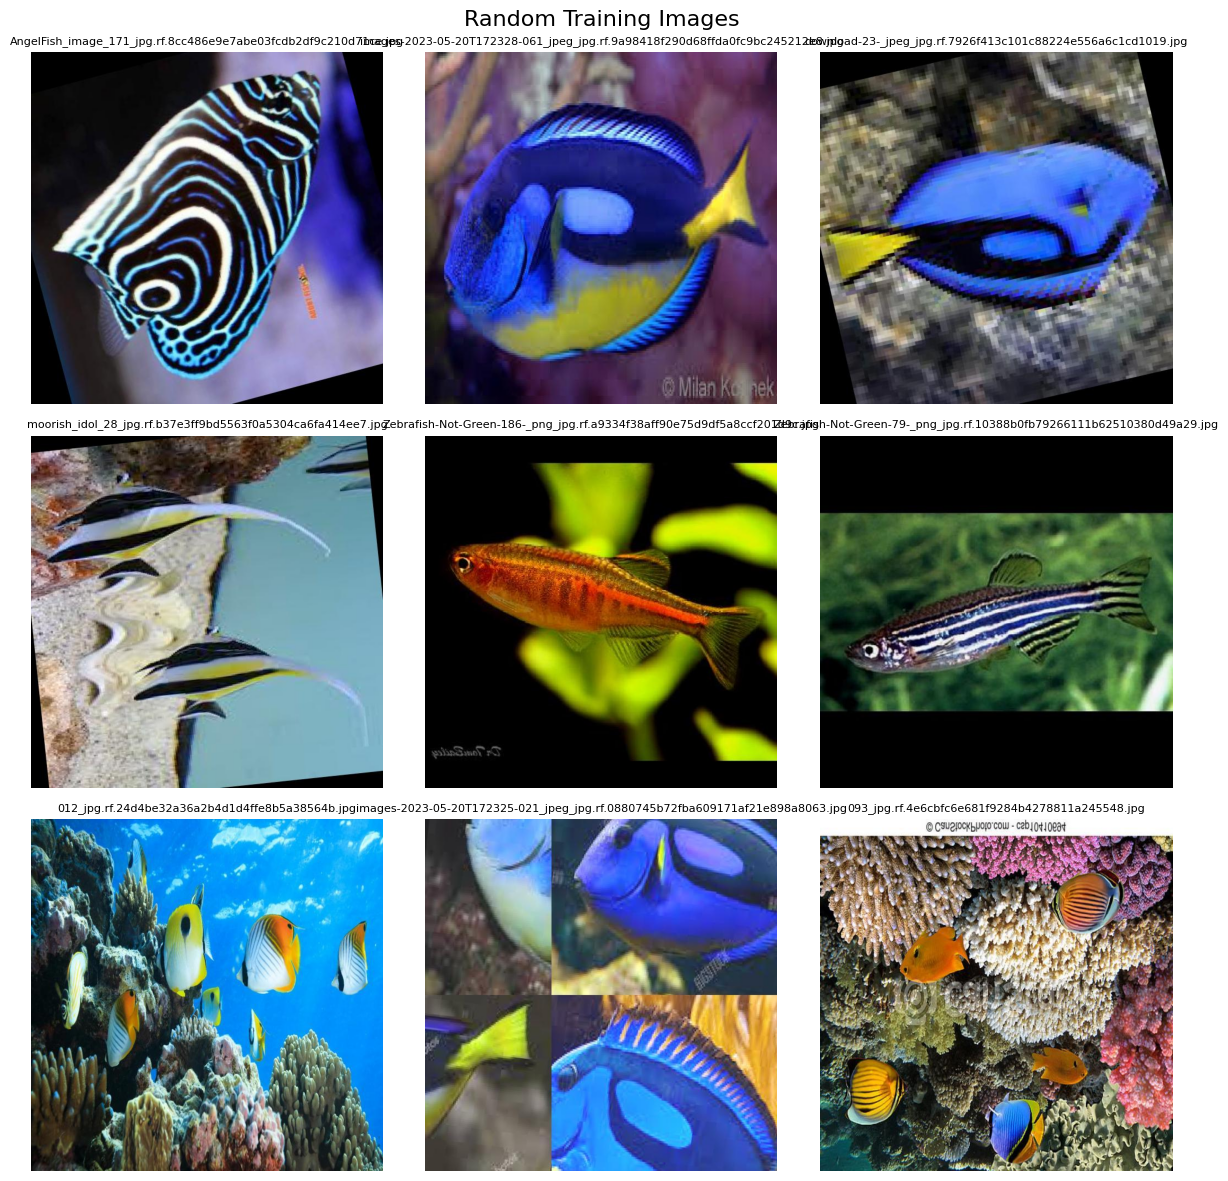

In [10]:
# Quick Sanity Check (Random Images)
import random
import matplotlib.pyplot as plt
from PIL import Image

image_files = list((LOCAL_DATASET / "train" / "images").glob("*.jpg"))

samples = random.sample(image_files, 9)

plt.figure(figsize=(12,12))

for i, img_path in enumerate(samples):

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.suptitle("Random Training Images", fontsize=16)

plt.tight_layout()

plt.show()

In [11]:
# ============================================================
# PART 2 — YOLOv8 Training
# ============================================================
DATA_YAML = LOCAL_DATASET / "data.yaml"

MODEL = "yolov8s.pt"          # good accuracy/speed balance on a T4; drop to yolov8n.pt if you want it even faster
EPOCHS = 60                   # patience below will stop early if it plateaus, so this is a ceiling not a target
IMAGE_SIZE = 640
BATCH_SIZE = 32               # T4 has room for this at 640px with yolov8s; drop to 16 if you hit CUDA OOM
PATIENCE = 15                 # stop early if val metrics don't improve for 15 epochs
RUN_NAME = "fish_yolov8s_colab"
RUNS_DIR = Path("/content/runs")

model = YOLO(MODEL)

print("Starting training...")
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=0,              # GPU 0 (the T4)
    workers=2,             # Colab gives ~2 CPU cores; more than this doesn't help and can stall the loader
    patience=PATIENCE,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    cache=False,           # dataset's already on local SSD, so caching to RAM buys little and risks OOM on 12GB RAM
    seed=42,
    deterministic=True,
    verbose=True,
    plots=True,
    save_period=5,         # checkpoint every 5 epochs, in case the session drops
    amp=True               # mixed precision — meaningful speedup on T4's tensor cores
)

run_dir = Path(results.save_dir)
print("Training complete. Run saved at:", run_dir)

Starting training...
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FishDetection.v5i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fish_yolov8s_col

In [12]:
model = YOLO(str(RUNS_DIR / RUN_NAME / "weights" / "last.pt"))
results = model.train(resume=True)

WARNING ⚠️ model '/content/runs/fish_yolov8s_colab/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line

Copying full run folder to Drive (weights + logs)...
Copied to: /content/drive/MyDrive/FishProjectOutputs/training/fish_yolov8s_colab


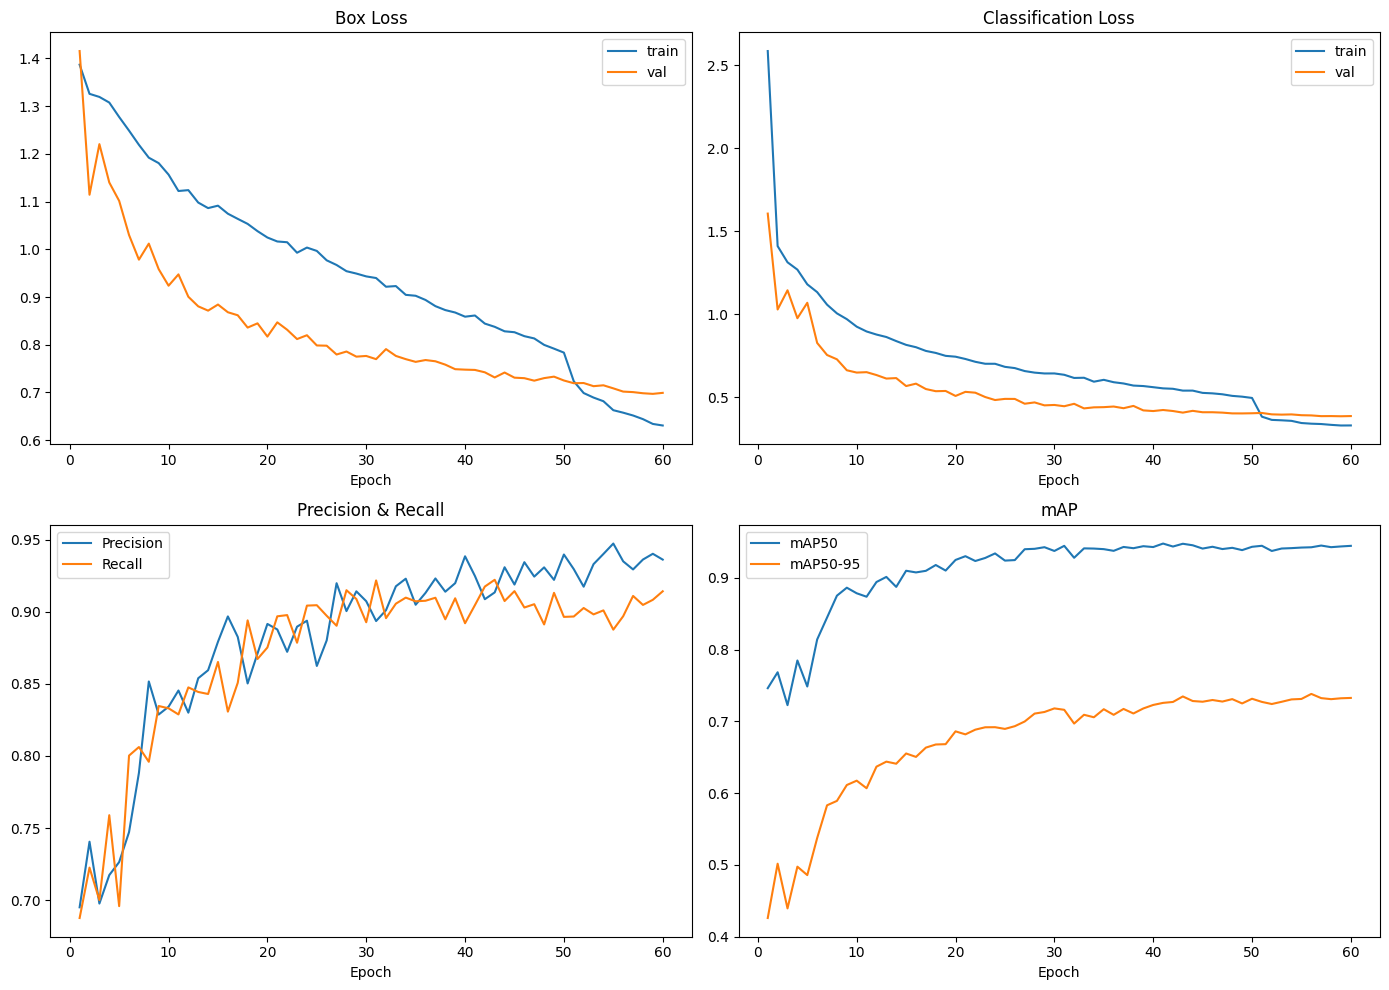

Best weights saved at: /content/drive/MyDrive/FishProjectOutputs/training/fish_yolov8s_colab/weights/best.pt
Everything is safely in Drive under: /content/drive/MyDrive/FishProjectOutputs


In [13]:
# ============================================================
# PART 3 — Save Model, Plots, CSVs to Drive
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

PERSIST_DIR = OUTPUT_DIR / "training" / RUN_NAME
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Copying full run folder to Drive (weights + logs)...")
if PERSIST_DIR.exists():
    shutil.rmtree(PERSIST_DIR)
shutil.copytree(run_dir, PERSIST_DIR)
print("Copied to:", PERSIST_DIR)

# ---- Parse results.csv into clean curves ----
results_csv = run_dir / "results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
df.to_csv(OUTPUT_DIR / "training_results.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0,0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0,0].set_title("Box Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[0,1].plot(df["epoch"], df["val/cls_loss"], label="val")
axes[0,1].set_title("Classification Loss"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

axes[1,0].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[1,0].plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
axes[1,0].set_title("Precision & Recall"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

axes[1,1].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[1,1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1,1].set_title("mAP"); axes[1,1].set_xlabel("Epoch"); axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=300)
plt.show()

# ---- Persist best-weights path for notebooks 03–07 ----
best_weights_drive = PERSIST_DIR / "weights" / "best.pt"
with open(OUTPUT_DIR / "best_weights_path.txt", "w") as f:
    f.write(str(best_weights_drive))

print("Best weights saved at:", best_weights_drive)
print("Everything is safely in Drive under:", OUTPUT_DIR)

# ---- Optional: download best.pt straight to your laptop ----
# from google.colab import files
# files.download(str(best_weights_drive))

In [16]:
!cat "/content/drive/MyDrive/FishProjectOutputs/training/fish_yolov8s_colab/args.yaml"

task: detect
mode: train
model: yolov8s.pt
data: /content/FishDetection.v5i.yolov11/data.yaml
epochs: 60
time: null
patience: 15
batch: 32
imgsz: 640
save: true
save_period: 5
cache: false
device: '0'
workers: 2
project: /content/runs
name: fish_yolov8s_colab
exist_ok: false
pretrained: true
cls_remap: true
optimizer: auto
verbose: true
seed: 42
deterministic: true
single_cls: false
rect: false
cos_lr: false
close_mosaic: 10
resume: false
amp: true
fraction: 1.0
profile: false
freeze: null
multi_scale: 0.0
compile: false
overlap_mask: true
mask_ratio: 4
dropout: 0.0
val: true
split: val
save_json: false
conf: null
iou: 0.7
max_det: 300
quantize: null
dnn: false
plots: true
end2end: null
source: null
vid_stride: 1
stream_buffer: false
visualize: false
augment: false
agnostic_nms: false
classes: null
retina_masks: false
embed: null
show: false
save_frames: false
save_txt: false
save_conf: false
save_crop: false
show_labels: true
show_conf: true
show_boxes: true
line_width: null
format: t

In [17]:
from pathlib import Path
print(Path("/content/runs/fish_yolov8s_colab/weights/best.pt").exists())

True


In [18]:
import shutil
from pathlib import Path

RUNS_DIR = Path("/content/runs")
CORRECT_RUN = RUNS_DIR / "fish_yolov8s_colab"
OUTPUT_DIR = Path("/content/drive/MyDrive/FishProjectOutputs")

PERSIST_DIR = OUTPUT_DIR / "training" / "fish_yolov8s_colab"
if PERSIST_DIR.exists():
    shutil.rmtree(PERSIST_DIR)
shutil.copytree(CORRECT_RUN, PERSIST_DIR)

best_weights_drive = PERSIST_DIR / "weights" / "best.pt"
with open(OUTPUT_DIR / "best_weights_path.txt", "w") as f:
    f.write(str(best_weights_drive))

print("Fixed. Weights now at:", best_weights_drive)

Fixed. Weights now at: /content/drive/MyDrive/FishProjectOutputs/training/fish_yolov8s_colab/weights/best.pt


Loading weights from: /content/drive/MyDrive/FishProjectOutputs/training/fish_yolov8s_colab/weights/best.pt
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,130,615 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 19.0±6.2 MB/s, size: 41.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/FishDetection.v5i.yolov11/test/labels... 683 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 683/683 552.5it/s 1.2s
val: New cache created: /content/FishDetection.v5i.yolov11/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 17, len(boxes) = 1115. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset

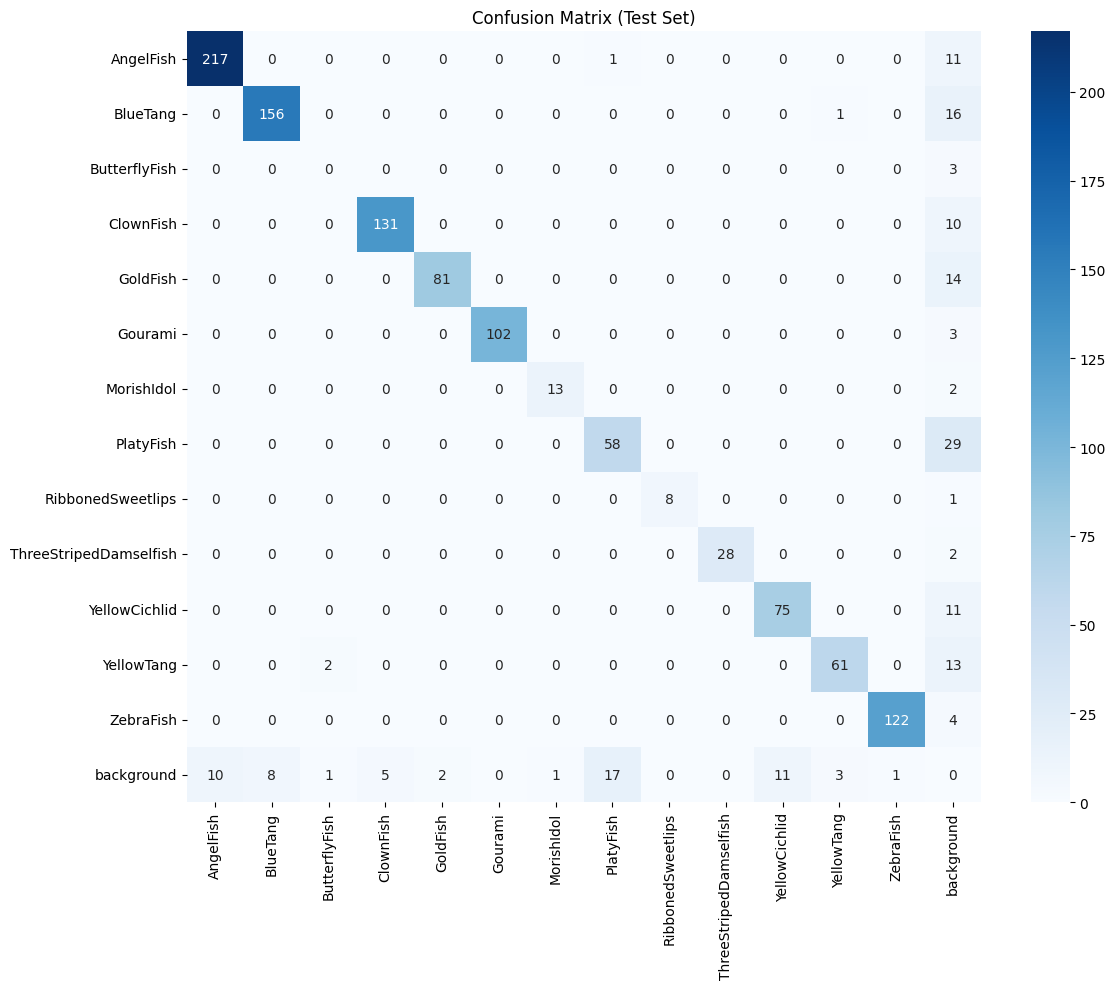

                     Class     TP    FP    FN
0                AngelFish  217.0  12.0  10.0
1                 BlueTang  156.0  17.0   8.0
2            ButterflyFish    0.0   3.0   3.0
3                ClownFish  131.0  10.0   5.0
4                 GoldFish   81.0  14.0   2.0
5                  Gourami  102.0   3.0   0.0
6               MorishIdol   13.0   2.0   1.0
7                PlatyFish   58.0  29.0  18.0
8        RibbonedSweetlips    8.0   1.0   0.0
9   ThreeStripedDamselfish   28.0   2.0   0.0
10           YellowCichlid   75.0  11.0  11.0
11              YellowTang   61.0  15.0   4.0
12               ZebraFish  122.0   4.0   1.0

Evaluation complete. Everything saved under: /content/drive/MyDrive/FishProjectOutputs/evaluation


In [19]:
### notebook 03
# ============================================================
# NOTEBOOK 03 — Model Evaluation on Test Set
# ============================================================
!pip install -q seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

EVAL_DIR = OUTPUT_DIR / "evaluation"
FIG_DIR = OUTPUT_DIR / "figures"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['AngelFish', 'BlueTang', 'ButterflyFish', 'ClownFish', 'GoldFish', 'Gourami', 'MorishIdol', 'PlatyFish', 'RibbonedSweetlips',
'ThreeStripedDamselfish', 'YellowCichlid', 'YellowTang', 'ZebraFish']

with open(OUTPUT_DIR / "best_weights_path.txt") as f:
    WEIGHTS_PATH = f.read().strip()

print("Loading weights from:", WEIGHTS_PATH)
model = YOLO(WEIGHTS_PATH)

# ----------------------------------------------------------------
# 1. Run official validation on the TEST split
# ----------------------------------------------------------------
metrics = model.val(
    data=str(LOCAL_DATASET / "data.yaml"),
    split="test",
    conf=0.25,
    iou=0.5,
    save_json=True,
    plots=True,
    project=str(EVAL_DIR),
    name="test_eval"
)

# ----------------------------------------------------------------
# 2. Per-class precision / recall / mAP / F1
# ----------------------------------------------------------------
per_class = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": metrics.box.p,
    "Recall": metrics.box.r,
    "mAP50": metrics.box.ap50,
    "mAP50-95": metrics.box.ap,
    "F1": metrics.box.f1
})
per_class.to_csv(EVAL_DIR / "per_class_metrics.csv", index=False)
print(per_class)

overall = {
    "Precision(mean)": metrics.box.mp,
    "Recall(mean)": metrics.box.mr,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
}
pd.Series(overall).to_csv(EVAL_DIR / "overall_metrics.csv")
print(overall)

# ----------------------------------------------------------------
# 3. Confusion matrix
# ----------------------------------------------------------------
cm = metrics.confusion_matrix.matrix
labels = CLASS_NAMES + ["background"]

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv(EVAL_DIR / "confusion_matrix_raw.csv")

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt=".0f", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=300)
plt.show()

# ----------------------------------------------------------------
# 4. TP / FP / FN per class
# ----------------------------------------------------------------
nc = len(CLASS_NAMES)
tp = np.diag(cm)[:nc]
fp = cm[:nc, :].sum(axis=1) - tp
fn = cm[:, :nc].sum(axis=0) - tp

tpfpfn = pd.DataFrame({"Class": CLASS_NAMES, "TP": tp, "FP": fp, "FN": fn})
tpfpfn.to_csv(EVAL_DIR / "tp_fp_fn_per_class.csv", index=False)
print(tpfpfn)

print("\nEvaluation complete. Everything saved under:", EVAL_DIR)

In [11]:
!pip install -q ultralytics

# import os
# import shutil
# from pathlib import Path

# import torch
# import yaml
# from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.0 MB/s eta 0:00:00


In [10]:
# ============================================================
# NOTEBOOK 04 — Fish Counting (inference on every test image)
# ============================================================
from pathlib import Path
import pandas as pd
from ultralytics import YOLO

COUNT_DIR = OUTPUT_DIR / "counting"
COUNT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['AngelFish', 'BlueTang', 'ButterflyFish', 'ClownFish', 'GoldFish',
               'Gourami', 'MorishIdol', 'PlatyFish', 'RibbonedSweetlips',
               'ThreeStripedDamselfish', 'YellowCichlid', 'YellowTang', 'ZebraFish']

with open(OUTPUT_DIR / "best_weights_path.txt") as f:
    WEIGHTS_PATH = f.read().strip()

model = YOLO(WEIGHTS_PATH)

TEST_IMG_DIR = LOCAL_DATASET / "test" / "images"
CONF_THRESHOLD = 0.25

per_image_rows = []
detection_records = []

# save=True writes annotated images to Drive under counting/predictions/
results = model.predict(
    source=str(TEST_IMG_DIR),
    conf=CONF_THRESHOLD,
    save=True,
    project=str(COUNT_DIR),
    name="predictions",
    verbose=False
)

for r in results:
    img_name = Path(r.path).name

    if r.boxes is not None and len(r.boxes) > 0:
        class_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs = r.boxes.conf.cpu().numpy()
    else:
        class_ids, confs = [], []

    counts = {name: 0 for name in CLASS_NAMES}
    for cid in class_ids:
        counts[CLASS_NAMES[cid]] += 1

    row = {"Image": img_name, "Total_Fish": len(class_ids)}
    row.update(counts)
    per_image_rows.append(row)

    for cid, conf in zip(class_ids, confs):
        detection_records.append({
            "Image": img_name,
            "Species": CLASS_NAMES[cid],
            "Confidence": float(conf)
        })

per_image_df = pd.DataFrame(per_image_rows)
per_image_df.to_csv(COUNT_DIR / "fish_counts_per_image.csv", index=False)

detections_df = pd.DataFrame(detection_records)
detections_df.to_csv(COUNT_DIR / "all_detections.csv", index=False)

species_totals = (
    detections_df["Species"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    .reset_index()
)
species_totals.columns = ["Species", "Total_Count"]
species_totals.to_csv(COUNT_DIR / "species_totals.csv", index=False)

print(per_image_df.head())
print(species_totals)
print(f"\nTotal images processed: {len(per_image_df)}")
print(f"Total fish detected: {detections_df.shape[0]}")
print("Fish counting complete. Annotated images saved in:", COUNT_DIR / "predictions")

ModuleNotFoundError: No module named 'ultralytics'